In [1]:
##install required packages
%pip install requests
%pip install requests beautifulsoup4
%pip install selenium
%pip install --upgrade openai
%pip install mplfinance

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


# Extract News
In this part, I will scrape one year’s worth of news from The Star, i3Investor, Yahoo Finance, and Free Malaysia Today, store them separately in different CSV files, and then merge them into a single file named NewsData.csv. Since each website has a different structure, I need to write separate code for each of them.

In [2]:
import os

BASE_DIR = "Source"
RAW_NEWS_DIR = os.path.join(BASE_DIR, "Data", "raw", "news")
PROCESSED_BASE = os.path.join(BASE_DIR, "Data", "processed", "news")

os.makedirs(RAW_NEWS_DIR, exist_ok=True)
os.makedirs(PROCESSED_BASE, exist_ok=True)

In [3]:
def get_last_date_from_csv(filename):
    if not os.path.exists(filename):
        return None
    df = pd.read_csv(filename)
    if df.empty:
        return None
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    return df["Date"].max().date()

def append_and_save(df_new, csv_file):
    if df_new is None or df_new.empty:
        print(f"No new data for {csv_file}")
        return
    if os.path.exists(csv_file):
        old = pd.read_csv(csv_file)
        old["Date"] = pd.to_datetime(old["Date"], errors="coerce")
        df_new["Date"] = pd.to_datetime(df_new["Date"], errors="coerce")
        df_all = pd.concat([old, df_new], ignore_index=True)
        df_all = df_all.drop_duplicates(subset=["Date", "News"])
        df_all = df_all.sort_values("Date")
        df_all.to_csv(csv_file, index=False)
    else:
        df_new.to_csv(csv_file, index=False)


In [4]:
COMPANIES = {
    "maybank": {
        "keyword": "maybank",
        "yahoo_ticker": "1155.KL",
        "i3_code": "1155",
        "file_prefix": "Maybank"
    },
    "public_bank": {
        "keyword": "public bank",
        "yahoo_ticker": "1295.KL",
        "i3_code": "1295",
        "file_prefix": "PublicBank"
    }
}

In [5]:
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException
from urllib.parse import quote_plus

def theStar(cfg):
    driver = webdriver.Chrome(options=options)
    url = f"https://www.thestar.com.my/search?query={cfg['keyword'].replace(' ', '%20')}"
    driver.get(url)
    
    csv_file = os.path.join(RAW_NEWS_DIR, f"{cfg['file_prefix']}_TheStarNews.csv")
    last_date = get_last_date_from_csv(csv_file)
    if last_date is None:
        time_constraint = datetime.today().date() - timedelta(days=730)
    else:
        time_constraint = last_date

    data = []
    stop = False

    while True:
        WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.ID, "resultdata"))
        )
        soup = BeautifulSoup(driver.page_source, "html.parser")

        nextPage = soup.find("div", {"id": "resultdata"})
        items = nextPage.find_all("div", class_="queryly_item_container")

        for item in items:
            date = item.find("span", class_="timestamp")
            if not date:
                continue

            date_text = date.get_text(strip=True).replace("[", "").replace("]", "")
            date_text = date_text.split("|")[0].strip()

            try:
                date_obj = pd.to_datetime(date_text, dayfirst=True, errors="coerce").date()
            except:
                continue

            if date_obj <= time_constraint:
                stop = True
                break

            title_tag = item.find("h2", class_="f18")
            if title_tag and title_tag.find("a"):
                link = title_tag.find("a")["href"]
                data.append({
                    "Date": date_obj,
                    "URL": link,
                    "News": ""
                })

        if stop:
            break

        try:
            first_link = WebDriverWait(driver, 10).until(
                EC.presence_of_element_located(
                    (By.CSS_SELECTOR, "#resultdata .queryly_item_container h2 a")
                )
            ).get_attribute("href")
            next_btn = WebDriverWait(driver, 5).until(
                EC.element_to_be_clickable((By.CSS_SELECTOR, "a.next_btn"))
            )
            driver.execute_script("arguments[0].click();", next_btn)
            WebDriverWait(driver, 10).until(
                lambda d: d.find_element(
                    By.CSS_SELECTOR,
                    "#resultdata .queryly_item_container h2 a"
                ).get_attribute("href") != first_link
            )
        except TimeoutException:
            print("No more next page or page did not change")
            break

    driver.quit()

    df_theStar = pd.DataFrame(data)

    driver = webdriver.Chrome(options=options)
    for idx, row in df_theStar.iterrows():
        url = row["URL"]
        try:
            driver.get(url)
            WebDriverWait(driver, 10).until(
                EC.presence_of_element_located((By.TAG_NAME, "body"))
            )
            soup = BeautifulSoup(driver.page_source, "html.parser")
            locked = soup.find("div", {"id": "divDefault", "class": "card"})
            if locked and locked.find("img") and "lock" in locked.find("img")["src"]:
                print(f"Skipping locked news: {url}")
                continue
            article = soup.find("div", {"id": "story-body"})
            if article is None:
                continue
            news = article.find_all("p")
            news_content = []
            for content in news:
                if content.find("img"):
                    continue
                if content.get("class") and "caption" in content.get("class"):
                    continue
                text = content.get_text(strip=True)
                if not text:
                    continue
                news_content.append(text)
            full_text = " ".join(news_content)
            df_theStar.at[idx, "News"] = full_text
        except Exception as e:
            print("Fail:", url, e)
    driver.quit()

    save_path = os.path.join(RAW_NEWS_DIR, f"{cfg['file_prefix']}_TheStarNews.csv")
    append_and_save(df_theStar, save_path)

    print(f"The Star - {cfg['file_prefix']}:")
    print(df_theStar)

def i3Investor(cfg):
    driver = webdriver.Chrome(options=options)
    url = f"https://klse.i3investor.com/web/stock/news-blogs/{cfg['i3_code']}"
    driver.get(url)
    time.sleep(3)

    soup = BeautifulSoup(driver.page_source, "html.parser")
    nextPage = soup.find("div", id="news-blog", class_="row m-0")
    nextPage2 = nextPage.find_all("div", class_="row m-0 mb-2")

    urlList = []
    for links in nextPage2:
        link = links.find("a", href=True)
        url1 = "https://klse.i3investor.com/" + link["href"]
        urlList.append(url1)

    csv_file = os.path.join(RAW_NEWS_DIR, f"{cfg['file_prefix']}_I3InvestorNews.csv")
    last_date = get_last_date_from_csv(csv_file)
    if last_date is None:
        time_constraint = datetime.today().date() - timedelta(days=730)
    else:
        time_constraint = last_date

    data = []

    for urls in urlList:
        driver.get(urls)
        time.sleep(1.5)

        soup = BeautifulSoup(driver.page_source, "html.parser")
        blog = soup.find("div", class_="row m-0 mt-1 px-1 pb-3 card disc-div")
        if blog is None:
            continue
        date = blog.find("h6", class_="subtitle small")
        if date is None:
            continue
        date_text = date.get_text(strip=True)
        parts = date_text.split(",")
        if len(parts) >= 3:
            date_text = parts[1].strip()
        date_obj = pd.to_datetime(date_text, dayfirst=True, errors="coerce")
        if pd.isna(date_obj):
            continue
        date_obj = date_obj.date()

        if date_obj <= time_constraint:
            break

        article = blog.find("div", class_="px-md-3 pt-2")
        if article is None:
            continue
        news = article.find_all(["p", "h3"])
        news_content = []
        for content in news:
            if content.find("img"):
                continue
            if content.get("class") and "caption" in content.get("class"):
                continue
            text = content.get_text(strip=True)
            if not text:
                continue
            news_content.append(text)
        full_text = " ".join(news_content)
        data.append({
            "Date": date_obj,
            "News": full_text
        })
    driver.quit()

    df_i3investor = pd.DataFrame(data)
    save_path = os.path.join(RAW_NEWS_DIR, f"{cfg['file_prefix']}_I3InvestorNews.csv")
    append_and_save(df_i3investor, save_path)

    print(f"I3 Investor - {cfg['file_prefix']}:")
    print(df_i3investor)

def yahooFinance(cfg):
    driver = webdriver.Chrome(options=options)
    url = f"https://finance.yahoo.com/quote/{cfg['yahoo_ticker']}/news/"
    driver.set_page_load_timeout(60)
    try:
        driver.get(url)
        WebDriverWait(driver, 30).until(
            EC.presence_of_element_located((By.TAG_NAME, "body"))
        )
    except TimeoutException:
        print("Yahoo Finance page timeout, skip.")
        driver.quit()
        return

    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(3)

    html = driver.page_source
    driver.quit()

    soup = BeautifulSoup(html, "html.parser")
    nextPage = soup.find("section", class_="mainContent")
    nextPage2 = nextPage.find_all("li", class_="stream-item story-item yf-9xydx9")
    urlList = []
    for links in nextPage2:
        link = links.find("a", href=True)
        urlList.append(link["href"])

    data = []

    driver = webdriver.Chrome(options=options)
    for urls in urlList:
        driver.get(urls)
        time.sleep(2)
        contentHTML = driver.page_source
        soup = BeautifulSoup(contentHTML, "html.parser")
        date = soup.find("time", class_="byline-attr-meta-time")
        if date is None:
            continue
        date_text = date.get_text(strip=True)
        try:
            date_obj = pd.to_datetime(date_text, dayfirst=True, errors="coerce").date()
        except:
            continue
        article = soup.find("div", class_="bodyItems-wrapper")
        if article is None:
            continue
        news = article.find_all("p")
        news_text = " ".join([content.text.strip() for content in news])
        data.append({"Date": date_obj, "News": news_text})
    driver.quit()

    df_yahooFinance = pd.DataFrame(data)

    csv_file = os.path.join(RAW_NEWS_DIR, f"{cfg['file_prefix']}_YahooFinanceNews.csv")
    last_date = get_last_date_from_csv(csv_file)
    if last_date is None:
        time_constraint = datetime.today().date() - timedelta(days=730)
    else:
        time_constraint = last_date

    df_yahooFinance = df_yahooFinance[(df_yahooFinance["Date"] > time_constraint)]
    save_path = os.path.join(RAW_NEWS_DIR, f"{cfg['file_prefix']}_YahooFinanceNews.csv")
    append_and_save(df_yahooFinance, save_path)

    print(f"Yahoo Finance - {cfg['file_prefix']}:")
    print(df_yahooFinance)

def freeMalaysiaToday(cfg):
    driver = webdriver.Chrome(options=options)
    url = f"https://www.freemalaysiatoday.com/search?term={cfg['keyword'].replace(' ', '%20')}&category=all"
    driver.get(url)
    time.sleep(5)

    csv_file = os.path.join(RAW_NEWS_DIR, f"{cfg['file_prefix']}_FreeMalaysiaTodayNews.csv")
    last_date = get_last_date_from_csv(csv_file)
    if last_date is None:
        time_constraint = datetime.today().date() - timedelta(days=730)
    else:
        time_constraint = last_date

    while True:
        soup = BeautifulSoup(driver.page_source, "html.parser")
        cards = soup.find_all("div", class_="relative grid w-full items-center gap-4")
        if not cards:
            break
        dates = []
        for item in cards:
            time_tag = item.find("time")
            if not time_tag:
                continue
            date_str = time_tag.get("datetime") or time_tag.get_text(strip=True)
            d = pd.to_datetime(date_str, errors="coerce")
            if not pd.isna(d):
                dates.append(d.date())
        if not dates:
            break
        oldest = min(dates)
        if oldest <= time_constraint:
            break
        try:
            view_more_btn = driver.find_element(
                By.XPATH, "//button[.//text()[contains(., 'View More')]]"
            )
            driver.execute_script("arguments[0].click();", view_more_btn)
            time.sleep(4)
        except:
            break

    time.sleep(5)
    html = driver.page_source
    driver.quit()

    soup = BeautifulSoup(html, "html.parser")
    nextPage = soup.find("section", class_="mt-4 flex flex-col gap-4")
    links = nextPage.find_all("div", class_="relative grid w-full items-center gap-4")

    urlList = []
    data = []
    for item in links:
        time_tag = item.find("time")
        if not time_tag or not time_tag.has_attr("datetime"):
            continue
        date_str = time_tag.get("datetime") or time_tag.get_text(strip=True)
        if not date_str:
            continue
        try:
            if "T" in date_str:
                date_obj = pd.to_datetime(date_str, errors="coerce").date()
            else:
                date_obj = pd.to_datetime(date_str, dayfirst=True, errors="coerce").date()
        except:
            continue
        if date_obj <= time_constraint:
            continue
        title_tag = item.find("div", class_="flex flex-col justify-around h-full")
        if title_tag and title_tag.find("a"):
            link = title_tag.find("a")["href"]
            url2 = "https://www.freemalaysiatoday.com" + link
            data.append({"Date": date_obj, "News": ""})
            urlList.append(url2)

    df_freeMalaysiaToday = pd.DataFrame(data)

    for idx, urls in enumerate(urlList):
        response = requests.get(urls)
        soup = BeautifulSoup(response.content, "html.parser")
        article = soup.find("article", class_="news-content")
        if article is None:
            continue
        news = article.find_all(["p", "div"], class_=re.compile("text-lg"))
        news_text = " ".join([content.text.strip() for content in news])
        df_freeMalaysiaToday.loc[idx, "News"] = news_text

    save_path = os.path.join(RAW_NEWS_DIR, f"{cfg['file_prefix']}_FreeMalaysiaTodayNews.csv")
    append_and_save(df_freeMalaysiaToday, save_path)
    print(f"Free Malaysia Today - {cfg['file_prefix']}:")
    print(df_freeMalaysiaToday)

In [6]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from bs4 import BeautifulSoup
from datetime import datetime, timedelta
import pandas as pd
import time
import requests
import re
import os

# Set up Chrome options
options = Options()
options.add_argument("--headless")  # Run in background
options.add_argument("--disable-gpu")
options.add_argument("--window-size=1920,1080")
options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64)")

RAW_NEWS_DIR = "Source/Data/raw/news" 
os.makedirs(RAW_NEWS_DIR, exist_ok=True)

def run_with_retry(fn, name, *args, retry=2, sleep_sec=10):
    for i in range(retry + 1):
        try:
            fn(*args)
            print(f"{name} success")
            return
        except Exception as e:
            print(f"{name} failed ({i+1}/{retry+1}):", e)
            if i < retry:
                time.sleep(sleep_sec)
    print(f"{name} finally failed, skip.")

def execute():
    for company_key, cfg in COMPANIES.items():
        print(f"\n===== SCRAPING {company_key.upper()} =====")
        run_with_retry(theStar, f"TheStar-{company_key}", cfg)
        run_with_retry(i3Investor, f"i3Investor-{company_key}", cfg)
        run_with_retry(yahooFinance, f"Yahoo-{company_key}", cfg)
        run_with_retry(freeMalaysiaToday, f"FMT-{company_key}", cfg)

execute()


===== SCRAPING MAYBANK =====


Fail: https://www.thestar.com.my/sport/golf/2025/08/14/thai-phoon-women-golfers-from-up-north-sweep-qualifying-spots-for-maybank-championship HTTPConnectionPool(host='localhost', port=45823): Read timed out. (read timeout=120)


The Star - Maybank:
           Date                                                URL  \
0    2026-04-02  https://www.thestar.com.my/sport/hockey/2026/0...   
1    2026-03-30  https://www.thestar.com.my/business/business-n...   
2    2026-03-30  https://www.thestar.com.my/business/business-n...   
3    2026-03-20  https://www.thestar.com.my/business/business-n...   
4    2026-03-19  https://www.thestar.com.my/business/business-n...   
..          ...                                                ...   
211  2024-10-27  https://www.thestar.com.my/aseanplus/aseanplus...   
212  2024-11-08  https://www.thestar.com.my/business/business-n...   
213  2025-01-07  https://www.thestar.com.my/business/business-n...   
214  2025-05-06  https://www.thestar.com.my/tech/tech-news/2025...   
215  2025-08-26  https://www.thestar.com.my/business/business-n...   

                                                  News  
0    PETALING JAYA: Maybank’s Muhajir Abdu Rauf is ...  
1    The maiden transacti

I3 Investor - Maybank:
           Date                                               News
0    2026-04-03  Elevated Volatility as Markets Continue to Rep...
1    2026-04-02  BNM’s 2H25 FSR underscores the banking sector’...
2    2026-04-02  Foreign turned net buying, buying SUNMED, IOIC...
3    2026-04-02  Eyeing 1,730 on De-escalation Hopes Key Market...
4    2026-04-01                    Source:RHB Research- 1 Apr 2026
..          ...                                                ...
303  2025-04-10  “Monetary policy cannot resolve trade wars. It...
304  2025-04-10  KUALA LUMPUR (April 9): AMMB Holdings Bhd's (K...
305  2025-04-10  Overnight US Rally to Cushion Local Market The...
306  2025-04-10  Relief Rally Expected Market Review MY:Selling...
307  2025-04-08  KUALA LUMPUR (April 7): Global markets were in...

[308 rows x 2 columns]
i3Investor-maybank success


Yahoo-maybank failed (1/3): 'Date'


...

I3 Investor - PublicBank:
           Date                                               News
0    2026-04-03  Executive Summary Malaysia’s equity market ent...
1    2026-04-03  Elevated Volatility as Markets Continue to Rep...
2    2026-04-02  Sign Up For Moomoo Account If you are a moomoo...
3    2026-04-02  Eyeing 1,730 on De-escalation Hopes Key Market...
4    2026-04-01                    Source:RHB Research- 1 Apr 2026
..          ...                                                ...
226  2025-04-18  KUALA LUMPUR (April 17): Malaysia’s richest ju...
227  2025-04-18                   Source:RHB Research- 18 Apr 2025
228  2025-04-17  KUALA LUMPUR (April 16): Malaysian banks, in s...
229  2025-04-16  Trade War Tensions Macro uncertainties have in...
230  2025-04-14  FBMKLCI Target Lowered to 1,660 due to Uncerta...

[231 rows x 2 columns]
i3Investor-public_bank success


Yahoo-public_bank failed (1/3): 'Date'


Yahoo-public_bank failed (2/3): 'Date'


Yahoo Finance page timeout, skip.
Yahoo-public_bank success


Free Malaysia Today - PublicBank:
          Date                                               News
0   2025-06-18  PUTRAJAYA: Mahkamah Persekutuan mengarahkan Pu...
1   2025-06-18  PUTRAJAYA: The Federal Court has ruled that Pu...
2   2025-05-26  PUTRAJAYA: Mahkamah Persekutuan sebulat suara ...
3   2025-05-26  PUTRAJAYA: The Federal Court has unanimously u...
4   2025-02-26  PETALING JAYA: Public Bank Bhd’s (PBB) net pro...
5   2024-10-10  KUALA LUMPUR: Public Bank Bhd is proposing to ...
6   2024-10-09  KUALA LUMPUR: Public Bank Bhd is considering b...
7   2024-09-09  PETALING JAYA: Public Bank Bhd, in a strategic...
8   2024-08-27  PETALING JAYA: Public Bank Bhd’s net profit ro...
9   2024-05-20  PETALING JAYA: Public Bank Bhd’s net profit fe...
10  2024-05-09  PUTRAJAYA: Public Bank Berhad yang didapati be...
11  2024-05-09  PUTRAJAYA: The National Feedlot Corporation (N...
FMT-public_bank success


In [7]:
import os
import re
import glob
import pandas as pd

RAW_NEWS_DIR = "Source/Data/raw/news"
PROCESSED_NEWS_DIR = "Source/Data/processed/news"
os.makedirs(PROCESSED_NEWS_DIR, exist_ok=True)

# Find all CSV files ending with "News.csv"
csv_files = glob.glob(os.path.join(RAW_NEWS_DIR, "*News.csv"))
print("News csv:", csv_files)

def infer_source_from_filename(filename):
    fname = os.path.basename(filename).lower()
    if "freemalaysiatoday" in fname:
        return "Free Malaysia Today"
    if "i3investor" in fname:
        return "i3Investor"
    if "thestar" in fname:
        return "The Star"
    if "yahoofinance" in fname:
        return "Yahoo Finance"
    return "Unknown"

def infer_bank_from_filename(filename):
    fname = os.path.basename(filename).lower()
    if fname.startswith("maybank_"):
        return "Maybank"
    if fname.startswith("publicbank_"):
        return "PublicBank"
    return "Unknown"

# ---------------------------
# 修复编码乱码
# ---------------------------
def fix_encoding(text):
    if not isinstance(text, str):
        return text
    try:
        return text.encode("latin1").decode("utf-8")
    except:
        return text

# ---------------------------
# 清理奇怪字符
# ---------------------------
def remove_weird_chars(text):
    if not isinstance(text, str):
        return text
    return re.sub(r'[^\w\s.,!?&\-\(\)/:;%$#@\'\"一-龥]', '', text)

# =============================
# 1. 读取并按银行分开
# =============================
maybank_list = []
publicbank_list = []

for f in csv_files:
    df = pd.read_csv(f, encoding="utf-8-sig")

    bank = infer_bank_from_filename(f)
    source = infer_source_from_filename(f)

    df["Source"] = source

    if "URL" in df.columns:
        df = df.drop(columns=["URL"])

    df = df[["Date", "News", "Source"]]
    df["News"] = df["News"].apply(fix_encoding).apply(remove_weird_chars)
    df = df.dropna(subset=["Date", "News"])

    if bank == "Maybank":
        maybank_list.append(df)
    elif bank == "PublicBank":
        publicbank_list.append(df)
    else:
        print(f"Skipping unknown bank file: {f}")

# =============================
# 2. 通用 merge function
# =============================
def merge_and_save(df_list, output_path):
    if len(df_list) == 0:
        print(f"No new raw news found for {output_path}")
        return

    new_df = pd.concat(df_list, ignore_index=True)

    if os.path.exists(output_path):
        old_df = pd.read_csv(output_path, encoding="utf-8-sig")
        print(f"Loaded existing {os.path.basename(output_path)}")
    else:
        old_df = pd.DataFrame(columns=["Date", "News", "Source"])

    all_df = pd.concat([old_df, new_df], ignore_index=True)

    # 去重：Date + News
    all_df = all_df.drop_duplicates(subset=["Date", "News"])

    # 排序：最新在上
    all_df["Date"] = pd.to_datetime(all_df["Date"], errors="coerce")
    all_df = all_df.dropna(subset=["Date"])
    all_df = all_df.sort_values(by="Date", ascending=False).reset_index(drop=True)

    all_df.to_csv(output_path, index=False, encoding="utf-8-sig")
    print(f"Merge complete for {os.path.basename(output_path)}. Total news: {len(all_df)}")

# =============================
# 3. 分别存档
# =============================
maybank_output = os.path.join(PROCESSED_NEWS_DIR, "NewsData.csv")
publicbank_output = os.path.join(PROCESSED_NEWS_DIR, "NewsDataPublicBank.csv")

merge_and_save(maybank_list, maybank_output)
merge_and_save(publicbank_list, publicbank_output)

News csv: ['Source/Data/raw/news/FreeMalaysiaTodayNews.csv', 'Source/Data/raw/news/PublicBank_FreeMalaysiaTodayNews.csv', 'Source/Data/raw/news/PublicBank_TheStarNews.csv', 'Source/Data/raw/news/PublicBank_I3InvestorNews.csv', 'Source/Data/raw/news/YahooFinanceNews.csv', 'Source/Data/raw/news/Maybank_TheStarNews.csv', 'Source/Data/raw/news/I3InvestorNews.csv', 'Source/Data/raw/news/Maybank_I3InvestorNews.csv', 'Source/Data/raw/news/TheStarNews.csv', 'Source/Data/raw/news/Maybank_FreeMalaysiaTodayNews.csv']
Skipping unknown bank file: Source/Data/raw/news/FreeMalaysiaTodayNews.csv
Skipping unknown bank file: Source/Data/raw/news/YahooFinanceNews.csv
Skipping unknown bank file: Source/Data/raw/news/I3InvestorNews.csv


Skipping unknown bank file: Source/Data/raw/news/TheStarNews.csv


Loaded existing NewsData.csv
Merge complete for NewsData.csv. Total news: 744
Merge complete for NewsDataPublicBank.csv. Total news: 470


# Perform Sentiment Analysis Using GPT API
In this part, I will use the GPT API (with gpt-5, or possibly other models) to perform sentiment analysis on each news article collected in the previous part. Then, I will group all the sentiment scores by date and calculate the average, using the average score to represent the sentiment for that day.

In [8]:
# for github security issue
import os
import pandas as pd
from openai import OpenAI
import time
import re

# 只从环境变量读取
API = os.getenv("OPENAI_API_KEY")

if not API:
    raise RuntimeError("OPENAI_API_KEY not found in environment variables")

# initialize OpenAI client
client = OpenAI(api_key=API)

In [9]:
import pandas as pd
from openai import OpenAI
import time
import re
import os

RAW_SENTIMENT_DIR = "Source/Data/raw/sentiment"
os.makedirs(RAW_SENTIMENT_DIR, exist_ok=True)

CONFIGS = [
    {
        "processed_news": "Source/Data/processed/news/NewsData.csv",
        "output_path": os.path.join(RAW_SENTIMENT_DIR, "gpt-5_sentiment.csv"),
        "company_name": "Maybank"
    },
    {
        "processed_news": "Source/Data/processed/news/NewsDataPublicBank.csv",
        "output_path": os.path.join(RAW_SENTIMENT_DIR, "gpt-5_sentiment_for_public_bank.csv"),
        "company_name": "Public Bank"
    }
]

def gpt_5_sentiment(news_text, company_name):
    prompt = f"""You are a financial analyst analyzing the news sentiment of {company_name}.
{news_text}
Review this news article and respond to its sentiment score (-1 to 1, 2 decimal places). For
example, respond `-1.00` when the article has a highly negative impact on the company,
respond `0.00` when the article is neutral or irrelevant, respond `1.00` when the article has
a highly positive impact on the company. You can have any number in between depending
on its sentiment. Respond with only 1 number and do not include any other words."""
    
    try:
        response = client.responses.create(
            model="gpt-5",
            input=[{"role": "user", "content": prompt}],
            reasoning={"effort": "minimal"}
        )

        text = response.output_text.strip()
        m = re.search(r"-?\d+(?:\.\d+)?", text)
        if m:
            return float(m.group())
        return None

    except Exception as e:
        print("Error:", e)
        return None

def process_sentiment_file(processed_news, output_path, company_name):
    news_df = pd.read_csv(processed_news)

    if os.path.exists(output_path):
        senti_df = pd.read_csv(output_path)
        print(f"Loaded existing sentiment file: {output_path}")

        if "Sentiment" not in senti_df.columns:
            senti_df["Sentiment"] = pd.NA

        df = pd.concat([senti_df, news_df], ignore_index=True)
        df = df.drop_duplicates(subset=["Date", "News"])

        if "Sentiment" not in df.columns:
            df["Sentiment"] = pd.NA
    else:
        df = news_df.copy()
        df["Sentiment"] = pd.NA

    for idx, row in df.iterrows():
        if pd.notna(row["Sentiment"]):
            continue

        score = gpt_5_sentiment(row["News"], company_name)
        df.loc[idx, "Sentiment"] = score
        print(f"[{company_name}] Processed {idx+1}/{len(df)} -> {score}")

        df.to_csv(output_path, index=False, encoding="utf-8-sig")
        time.sleep(3)

    print(f"Sentiment analysis done for {company_name}, saved to: {output_path}")

for cfg in CONFIGS:
    process_sentiment_file(
        processed_news=cfg["processed_news"],
        output_path=cfg["output_path"],
        company_name=cfg["company_name"]
    )

Loaded existing sentiment file: Source/Data/raw/sentiment/gpt-5_sentiment.csv


[Maybank] Processed 638/744 -> 0.82


[Maybank] Processed 639/744 -> 0.7


[Maybank] Processed 642/744 -> 0.35


[Maybank] Processed 643/744 -> -0.1


...

[Public Bank] Processed 467/470 -> -0.4


[Public Bank] Processed 468/470 -> -0.3


[Public Bank] Processed 469/470 -> 0.4


[Public Bank] Processed 470/470 -> 0.0


Sentiment analysis done for Public Bank, saved to: Source/Data/raw/sentiment/gpt-5_sentiment_for_public_bank.csv


In [10]:
import pandas as pd
import os

RAW_SENTIMENT_DIR = "Source/Data/raw/sentiment"
PROCESSED_SENTIMENT_DIR = "Source/Data/processed/sentiment"
os.makedirs(PROCESSED_SENTIMENT_DIR, exist_ok=True)

CONFIGS = [
    {
        "input_file": "gpt-5_sentiment.csv",
        "output_file": "gpt-5_avg_sentiment.csv",
        "name": "Maybank"
    },
    {
        "input_file": "gpt-5_sentiment_for_public_bank.csv",
        "output_file": "gpt-5_avg_sentiment_public_bank.csv",
        "name": "Public Bank"
    }
]

def process_avg_sentiment(input_file, output_file, name):
    input_path = os.path.join(RAW_SENTIMENT_DIR, input_file)
    
    if not os.path.exists(input_path):
        print(f"{name}: file not found -> {input_path}")
        return
    
    df_sentiment = pd.read_csv(input_path)

    # 确保 Sentiment 是 float
    df_sentiment["Sentiment"] = pd.to_numeric(df_sentiment["Sentiment"], errors="coerce")

    # 按日期取平均
    df_avg = df_sentiment.groupby("Date", as_index=False)["Sentiment"].mean()

    # 保留4位小数
    df_avg["Sentiment"] = df_avg["Sentiment"].round(4)

    # 日期排序（最新在上）
    df_avg = df_avg.sort_values(by="Date", ascending=False)

    # 存档
    output_path = os.path.join(PROCESSED_SENTIMENT_DIR, output_file)
    df_avg.to_csv(output_path, index=False, encoding="utf-8-sig")

    print(f"{name}: Average sentiment saved to -> {output_path}")

# 一次跑两家
for cfg in CONFIGS:
    process_avg_sentiment(
        input_file=cfg["input_file"],
        output_file=cfg["output_file"],
        name=cfg["name"]
    )

Maybank: Average sentiment saved to -> Source/Data/processed/sentiment/gpt-5_avg_sentiment.csv
Public Bank: Average sentiment saved to -> Source/Data/processed/sentiment/gpt-5_avg_sentiment_public_bank.csv


In [11]:
import pandas as pd
from openai import OpenAI
import time
import re
import os

RAW_SENTIMENT_DIR = "Source/Data/raw/sentiment"
os.makedirs(RAW_SENTIMENT_DIR, exist_ok=True)

CONFIGS = [
    {
        "processed_news": "Source/Data/processed/news/NewsData.csv",
        "output_path": os.path.join(RAW_SENTIMENT_DIR, "gpt-5-mini_sentiment.csv"),
        "company_name": "Maybank"
    },
    {
        "processed_news": "Source/Data/processed/news/NewsDataPublicBank.csv",
        "output_path": os.path.join(RAW_SENTIMENT_DIR, "gpt-5-mini_sentiment_for_public_bank.csv"),
        "company_name": "Public Bank"
    }
]

def gpt_5_sentiment(news_text, company_name):
    prompt = f"""You are a financial analyst analyzing the news sentiment of {company_name}.
{news_text}
Review this news article and respond to its sentiment score (-1 to 1, 2 decimal places). For
example, respond `-1.00` when the article has a highly negative impact on the company,
respond `0.00` when the article is neutral or irrelevant, respond `1.00` when the article has
a highly positive impact on the company. You can have any number in between depending
on its sentiment. Respond with only 1 number and do not include any other words."""
    
    try:
        response = client.responses.create(
            model="gpt-5",
            input=[{"role": "user", "content": prompt}],
            reasoning={"effort": "minimal"}
        )

        text = response.output_text.strip()
        m = re.search(r"-?\d+(?:\.\d+)?", text)
        if m:
            return float(m.group())
        return None

    except Exception as e:
        print("Error:", e)
        return None

def process_sentiment_file(processed_news, output_path, company_name):
    news_df = pd.read_csv(processed_news)

    if os.path.exists(output_path):
        senti_df = pd.read_csv(output_path)
        print(f"Loaded existing sentiment file: {output_path}")

        if "Sentiment" not in senti_df.columns:
            senti_df["Sentiment"] = pd.NA

        df = pd.concat([senti_df, news_df], ignore_index=True)
        df = df.drop_duplicates(subset=["Date", "News"])

        if "Sentiment" not in df.columns:
            df["Sentiment"] = pd.NA
    else:
        df = news_df.copy()
        df["Sentiment"] = pd.NA

    for idx, row in df.iterrows():
        if pd.notna(row["Sentiment"]):
            continue

        score = gpt_5_sentiment(row["News"], company_name)
        df.loc[idx, "Sentiment"] = score
        print(f"[{company_name}] Processed {idx+1}/{len(df)} -> {score}")

        df.to_csv(output_path, index=False, encoding="utf-8-sig")
        time.sleep(3)

    print(f"Sentiment analysis done for {company_name}, saved to: {output_path}")

for cfg in CONFIGS:
    process_sentiment_file(
        processed_news=cfg["processed_news"],
        output_path=cfg["output_path"],
        company_name=cfg["company_name"]
    )

Loaded existing sentiment file: Source/Data/raw/sentiment/gpt-5-mini_sentiment.csv


[Maybank] Processed 638/744 -> 0.79


[Maybank] Processed 639/744 -> 0.7


[Maybank] Processed 642/744 -> 0.35


[Maybank] Processed 643/744 -> 0.1


...

[Public Bank] Processed 467/470 -> -0.35


[Public Bank] Processed 468/470 -> -0.3


[Public Bank] Processed 469/470 -> 0.4


[Public Bank] Processed 470/470 -> 0.0


Sentiment analysis done for Public Bank, saved to: Source/Data/raw/sentiment/gpt-5-mini_sentiment_for_public_bank.csv


In [12]:
import pandas as pd
import os

RAW_SENTIMENT_DIR = "Source/Data/raw/sentiment"
PROCESSED_SENTIMENT_DIR = "Source/Data/processed/sentiment"
os.makedirs(PROCESSED_SENTIMENT_DIR, exist_ok=True)

CONFIGS = [
    {
        "input_file": "gpt-5-mini_sentiment.csv",
        "output_file": "gpt-5-mini_avg_sentiment.csv",
        "name": "Maybank"
    },
    {
        "input_file": "gpt-5-mini_sentiment_for_public_bank.csv",
        "output_file": "gpt-5-mini_avg_sentiment_public_bank.csv",
        "name": "Public Bank"
    }
]

def process_avg_sentiment(input_file, output_file, name):
    input_path = os.path.join(RAW_SENTIMENT_DIR, input_file)
    
    if not os.path.exists(input_path):
        print(f"{name}: file not found -> {input_path}")
        return
    
    df_sentiment = pd.read_csv(input_path)

    # 确保 Sentiment 是 float
    df_sentiment["Sentiment"] = pd.to_numeric(df_sentiment["Sentiment"], errors="coerce")

    # 按日期取平均
    df_avg = df_sentiment.groupby("Date", as_index=False)["Sentiment"].mean()

    # 保留4位小数
    df_avg["Sentiment"] = df_avg["Sentiment"].round(4)

    # 日期排序（最新在上）
    df_avg = df_avg.sort_values(by="Date", ascending=False)

    # 存档
    output_path = os.path.join(PROCESSED_SENTIMENT_DIR, output_file)
    df_avg.to_csv(output_path, index=False, encoding="utf-8-sig")

    print(f"{name}: Average sentiment saved to -> {output_path}")

# 一次跑两家
for cfg in CONFIGS:
    process_avg_sentiment(
        input_file=cfg["input_file"],
        output_file=cfg["output_file"],
        name=cfg["name"]
    )

Maybank: Average sentiment saved to -> Source/Data/processed/sentiment/gpt-5-mini_avg_sentiment.csv
Public Bank: Average sentiment saved to -> Source/Data/processed/sentiment/gpt-5-mini_avg_sentiment_public_bank.csv


In [13]:
import pandas as pd
from openai import OpenAI
import time
import re
import os

RAW_SENTIMENT_DIR = "Source/Data/raw/sentiment"
os.makedirs(RAW_SENTIMENT_DIR, exist_ok=True)

CONFIGS = [
    {
        "processed_news": "Source/Data/processed/news/NewsData.csv",
        "output_path": os.path.join(RAW_SENTIMENT_DIR, "gpt-5-nano_sentiment.csv"),
        "company_name": "Maybank"
    },
    {
        "processed_news": "Source/Data/processed/news/NewsDataPublicBank.csv",
        "output_path": os.path.join(RAW_SENTIMENT_DIR, "gpt-5-nano_sentiment_for_public_bank.csv"),
        "company_name": "Public Bank"
    }
]

def gpt_5_sentiment(news_text, company_name):
    prompt = f"""You are a financial analyst analyzing the news sentiment of {company_name}.
{news_text}
Review this news article and respond to its sentiment score (-1 to 1, 2 decimal places). For
example, respond `-1.00` when the article has a highly negative impact on the company,
respond `0.00` when the article is neutral or irrelevant, respond `1.00` when the article has
a highly positive impact on the company. You can have any number in between depending
on its sentiment. Respond with only 1 number and do not include any other words."""
    
    try:
        response = client.responses.create(
            model="gpt-5",
            input=[{"role": "user", "content": prompt}],
            reasoning={"effort": "minimal"}
        )

        text = response.output_text.strip()
        m = re.search(r"-?\d+(?:\.\d+)?", text)
        if m:
            return float(m.group())
        return None

    except Exception as e:
        print("Error:", e)
        return None

def process_sentiment_file(processed_news, output_path, company_name):
    news_df = pd.read_csv(processed_news)

    if os.path.exists(output_path):
        senti_df = pd.read_csv(output_path)
        print(f"Loaded existing sentiment file: {output_path}")

        if "Sentiment" not in senti_df.columns:
            senti_df["Sentiment"] = pd.NA

        df = pd.concat([senti_df, news_df], ignore_index=True)
        df = df.drop_duplicates(subset=["Date", "News"])

        if "Sentiment" not in df.columns:
            df["Sentiment"] = pd.NA
    else:
        df = news_df.copy()
        df["Sentiment"] = pd.NA

    for idx, row in df.iterrows():
        if pd.notna(row["Sentiment"]):
            continue

        score = gpt_5_sentiment(row["News"], company_name)
        df.loc[idx, "Sentiment"] = score
        print(f"[{company_name}] Processed {idx+1}/{len(df)} -> {score}")

        df.to_csv(output_path, index=False, encoding="utf-8-sig")
        time.sleep(3)

    print(f"Sentiment analysis done for {company_name}, saved to: {output_path}")

for cfg in CONFIGS:
    process_sentiment_file(
        processed_news=cfg["processed_news"],
        output_path=cfg["output_path"],
        company_name=cfg["company_name"]
    )

Loaded existing sentiment file: Source/Data/raw/sentiment/gpt-5-nano_sentiment.csv


[Maybank] Processed 638/744 -> 0.78


[Maybank] Processed 639/744 -> 0.7


[Maybank] Processed 642/744 -> 0.35


[Maybank] Processed 643/744 -> -0.1


...

[Public Bank] Processed 467/470 -> -0.4


[Public Bank] Processed 468/470 -> -0.2


[Public Bank] Processed 469/470 -> 0.38


[Public Bank] Processed 470/470 -> 0.0


Sentiment analysis done for Public Bank, saved to: Source/Data/raw/sentiment/gpt-5-nano_sentiment_for_public_bank.csv


In [14]:
import pandas as pd
import os

RAW_SENTIMENT_DIR = "Source/Data/raw/sentiment"
PROCESSED_SENTIMENT_DIR = "Source/Data/processed/sentiment"
os.makedirs(PROCESSED_SENTIMENT_DIR, exist_ok=True)

CONFIGS = [
    {
        "input_file": "gpt-5-nano_sentiment.csv",
        "output_file": "gpt-5-nano_avg_sentiment.csv",
        "name": "Maybank"
    },
    {
        "input_file": "gpt-5-nano_sentiment_for_public_bank.csv",
        "output_file": "gpt-5-nano_avg_sentiment_public_bank.csv",
        "name": "Public Bank"
    }
]

def process_avg_sentiment(input_file, output_file, name):
    input_path = os.path.join(RAW_SENTIMENT_DIR, input_file)
    
    if not os.path.exists(input_path):
        print(f"{name}: file not found -> {input_path}")
        return
    
    df_sentiment = pd.read_csv(input_path)

    # 确保 Sentiment 是 float
    df_sentiment["Sentiment"] = pd.to_numeric(df_sentiment["Sentiment"], errors="coerce")

    # 按日期取平均
    df_avg = df_sentiment.groupby("Date", as_index=False)["Sentiment"].mean()

    # 保留4位小数
    df_avg["Sentiment"] = df_avg["Sentiment"].round(4)

    # 日期排序（最新在上）
    df_avg = df_avg.sort_values(by="Date", ascending=False)

    # 存档
    output_path = os.path.join(PROCESSED_SENTIMENT_DIR, output_file)
    df_avg.to_csv(output_path, index=False, encoding="utf-8-sig")

    print(f"{name}: Average sentiment saved to -> {output_path}")

# 一次跑两家
for cfg in CONFIGS:
    process_avg_sentiment(
        input_file=cfg["input_file"],
        output_file=cfg["output_file"],
        name=cfg["name"]
    )

Maybank: Average sentiment saved to -> Source/Data/processed/sentiment/gpt-5-nano_avg_sentiment.csv
Public Bank: Average sentiment saved to -> Source/Data/processed/sentiment/gpt-5-nano_avg_sentiment_public_bank.csv


# Extract Stock Data
In this part, I extract one year of stock data from Yahoo Finance and plot the closing price line chart. The closing price is particularly important in stock market analysis because it reflects the final consensus value of the stock for the day, often used by analysts and investors as a benchmark for identifying trends, calculating returns, and applying technical indicators.

In [15]:
import yfinance as yf
import pandas as pd
import os

RAW_STOCK_DIR = "Source/Data/raw/stock"
os.makedirs(RAW_STOCK_DIR, exist_ok=True)

CONFIGS = [
    {
        "ticker": "1155.KL",
        "file_name": "Maybank_Stocks_Data.csv",
        "name": "Maybank"
    },
    {
        "ticker": "1295.KL",
        "file_name": "Public_Bank_Stocks_Data.csv",
        "name": "Public Bank"
    }
]

start_dt = "2024-03-01"

def download_and_save_stock(cfg):
    ticker = cfg["ticker"]
    output_path = os.path.join(RAW_STOCK_DIR, cfg["file_name"])

    print(f"\nDownloading {cfg['name']} ({ticker})...")

    df = yf.download(ticker, start=start_dt)

    # 如果是 multi-index（有 ticker layer）
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel(1)

    df = df.reset_index()[["Date", "Open", "Close"]]

    if os.path.exists(output_path):
        old_df = pd.read_csv(output_path)
        old_df["Date"] = pd.to_datetime(old_df["Date"])

        combined = pd.concat([old_df, df], ignore_index=True)
        combined = combined.drop_duplicates(subset=["Date"])
        combined = combined.sort_values("Date", ascending=True)
    else:
        combined = df.copy()

    combined.to_csv(output_path, index=False, encoding="utf-8-sig")

    print(f"Saved {cfg['name']} stock data to:", output_path)
    print(combined.tail())

# 一次跑两只股票
for cfg in CONFIGS:
    download_and_save_stock(cfg)

[*********************100%***********************]  1 of 1 completed

Saved Maybank stock data to: Source/Data/raw/stock/Maybank_Stocks_Data.csv
          Date   Open  Close
508 2026-03-30  11.40  11.20
509 2026-03-31  11.24  11.36
510 2026-04-01  11.54  11.66
511 2026-04-02  11.70  11.46
512 2026-04-03  11.52  11.26



[*********************100%***********************]  1 of 1 completed

Saved Public Bank stock data to: Source/Data/raw/stock/Public_Bank_Stocks_Data.csv
Price       Date  Open  Close
508   2026-03-30  4.75   4.66
509   2026-03-31  4.67   4.68
510   2026-04-01  4.75   4.77
511   2026-04-02  4.77   4.71
512   2026-04-03  4.75   4.66


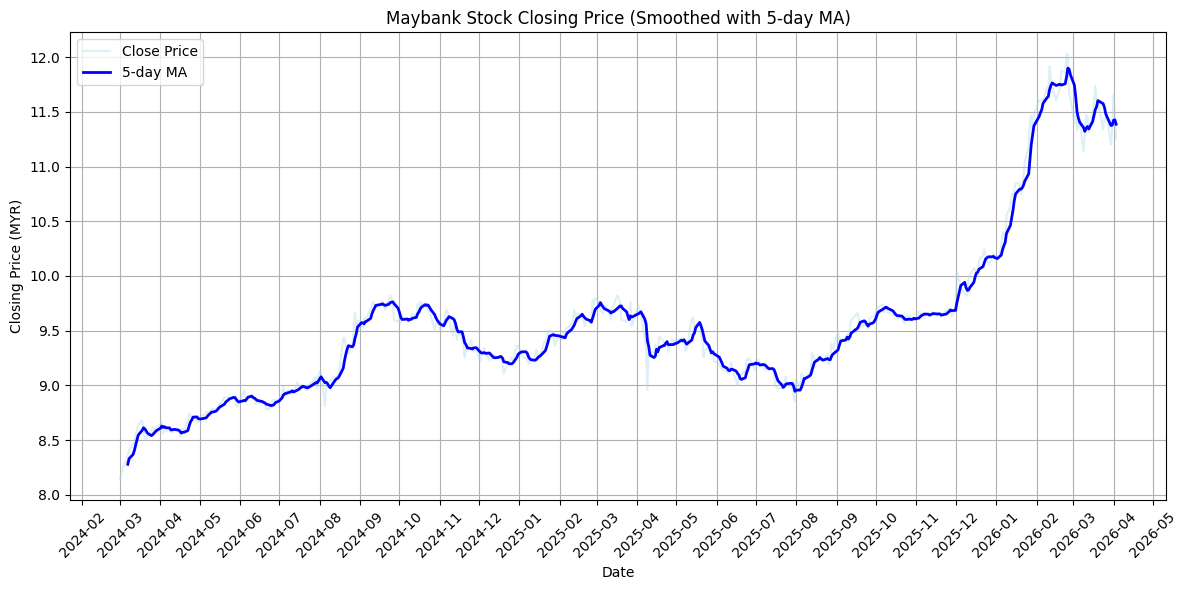

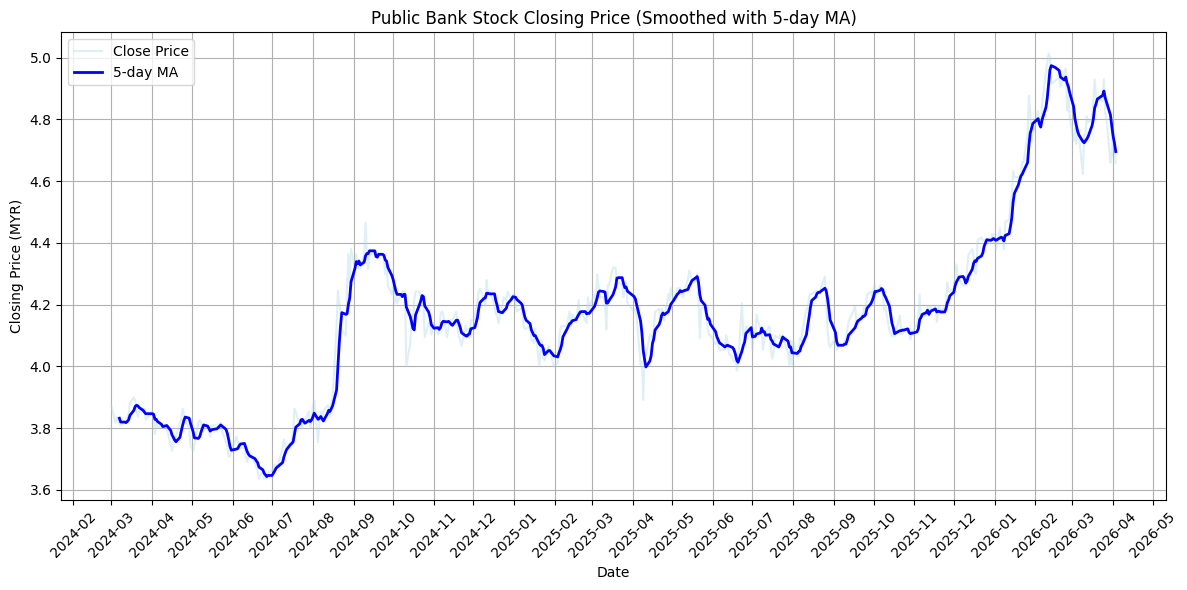

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_stock_ma(file_path, title):
    df = pd.read_csv(file_path)
    df["Date"] = pd.to_datetime(df["Date"])
    df["Close"] = pd.to_numeric(df["Close"], errors='coerce')

    # 计算 5-day MA
    df["Close_MA5"] = df["Close"].rolling(window=5).mean()

    plt.figure(figsize=(12, 6))

    # 原始价格
    plt.plot(df["Date"], df["Close"], color='lightblue', alpha=0.4, label="Close Price")

    # MA5
    plt.plot(df["Date"], df["Close_MA5"], color='blue', linewidth=2, label="5-day MA")

    # 日期格式
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Closing Price (MYR)")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


# 🔵 Maybank 图
plot_stock_ma(
    "Source/Data/raw/stock/Maybank_Stocks_Data.csv",
    "Maybank Stock Closing Price (Smoothed with 5-day MA)"
)

# 🟢 Public Bank 图
plot_stock_ma(
    "Source/Data/raw/stock/Public_Bank_Stocks_Data.csv",
    "Public Bank Stock Closing Price (Smoothed with 5-day MA)"
)

# Align Data
Merge the sentiment scores and stock closing price based on the same date

In [17]:
import pandas as pd
import os

OUTPUT_DIR = "Source/Data/processed/forARDL"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CONFIGS = [
    {
        "stock_path": "Source/Data/raw/stock/Maybank_Stocks_Data.csv",
        "sentiment_path": "Source/Data/processed/sentiment/gpt-5_avg_sentiment.csv",
        "output_file": "gpt-5_And_Closing_Price.csv",
        "name": "Maybank"
    },
    {
        "stock_path": "Source/Data/raw/stock/Public_Bank_Stocks_Data.csv",
        "sentiment_path": "Source/Data/processed/sentiment/gpt-5_avg_sentiment_public_bank.csv",
        "output_file": "gpt-5_And_Closing_Price_for_Public_Bank.csv",
        "name": "Public Bank"
    }
]

def merge_stock_sentiment(cfg):
    print(f"\nProcessing {cfg['name']}...")

    stocks = pd.read_csv(cfg["stock_path"])
    sentiment = pd.read_csv(cfg["sentiment_path"])

    # 日期格式
    stocks["Date"] = pd.to_datetime(stocks["Date"])
    sentiment["Date"] = pd.to_datetime(sentiment["Date"])

    # 只保留 Close
    stocks_close = stocks[["Date", "Close"]]

    # merge（以 stock 为主）
    merged_df = pd.merge(sentiment, stocks_close, on="Date", how="right")

    # 排序（最新在上）
    merged_df = merged_df.sort_values("Date", ascending=False).reset_index(drop=True)

    # sentiment 转 numeric + fill 0
    merged_df["Sentiment"] = pd.to_numeric(merged_df["Sentiment"], errors="coerce")
    merged_df["Sentiment"] = merged_df["Sentiment"].fillna(0)

    # 存档
    output_path = os.path.join(OUTPUT_DIR, cfg["output_file"])
    merged_df.to_csv(output_path, index=False, encoding="utf-8-sig")

    print(f"{cfg['name']} merge complete → {output_path}")
    print(merged_df.head())

# 跑两只股票
for cfg in CONFIGS:
    merge_stock_sentiment(cfg)


Processing Maybank...
Maybank merge complete → Source/Data/processed/forARDL/gpt-5_And_Closing_Price.csv
        Date  Sentiment  Close
0 2026-04-03    -0.3000  11.26
1 2026-04-02     0.3500  11.46
2 2026-04-01     0.2750  11.66
3 2026-03-31     0.0000  11.36
4 2026-03-30     0.6667  11.20

Processing Public Bank...
Public Bank merge complete → Source/Data/processed/forARDL/gpt-5_And_Closing_Price_for_Public_Bank.csv
        Date  Sentiment  Close
0 2026-04-03    -0.0583   4.66
1 2026-04-02     0.3333   4.71
2 2026-04-01     0.0667   4.77
3 2026-03-31     0.1760   4.68
4 2026-03-30    -0.1000   4.66


In [18]:
import pandas as pd
import os

OUTPUT_DIR = "Source/Data/processed/forARDL"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CONFIGS = [
    {
        "stock_path": "Source/Data/raw/stock/Maybank_Stocks_Data.csv",
        "sentiment_path": "Source/Data/processed/sentiment/gpt-5-mini_avg_sentiment.csv",
        "output_file": "gpt-5-mini_And_Closing_Price.csv",
        "name": "Maybank"
    },
    {
        "stock_path": "Source/Data/raw/stock/Public_Bank_Stocks_Data.csv",
        "sentiment_path": "Source/Data/processed/sentiment/gpt-5-mini_avg_sentiment_public_bank.csv",
        "output_file": "gpt-5-mini_And_Closing_Price_for_Public_Bank.csv",
        "name": "Public Bank"
    }
]

def merge_stock_sentiment(cfg):
    print(f"\nProcessing {cfg['name']}...")

    stocks = pd.read_csv(cfg["stock_path"])
    sentiment = pd.read_csv(cfg["sentiment_path"])

    # 日期格式
    stocks["Date"] = pd.to_datetime(stocks["Date"])
    sentiment["Date"] = pd.to_datetime(sentiment["Date"])

    # 只保留 Close
    stocks_close = stocks[["Date", "Close"]]

    # merge（以 stock 为主）
    merged_df = pd.merge(sentiment, stocks_close, on="Date", how="right")

    # 排序（最新在上）
    merged_df = merged_df.sort_values("Date", ascending=False).reset_index(drop=True)

    # sentiment 转 numeric + fill 0
    merged_df["Sentiment"] = pd.to_numeric(merged_df["Sentiment"], errors="coerce")
    merged_df["Sentiment"] = merged_df["Sentiment"].fillna(0)

    # 存档
    output_path = os.path.join(OUTPUT_DIR, cfg["output_file"])
    merged_df.to_csv(output_path, index=False, encoding="utf-8-sig")

    print(f"{cfg['name']} merge complete → {output_path}")
    print(merged_df.head())

# 跑两只股票
for cfg in CONFIGS:
    merge_stock_sentiment(cfg)


Processing Maybank...
Maybank merge complete → Source/Data/processed/forARDL/gpt-5-mini_And_Closing_Price.csv
        Date  Sentiment  Close
0 2026-04-03    -0.4500  11.26
1 2026-04-02     0.3250  11.46
2 2026-04-01     0.2750  11.66
3 2026-03-31     0.0000  11.36
4 2026-03-30     0.6367  11.20

Processing Public Bank...
Public Bank merge complete → Source/Data/processed/forARDL/gpt-5-mini_And_Closing_Price_for_Public_Bank.csv
        Date  Sentiment  Close
0 2026-04-03    -0.0583   4.66
1 2026-04-02     0.3167   4.71
2 2026-04-01     0.0500   4.77
3 2026-03-31     0.2440   4.68
4 2026-03-30    -0.0875   4.66


In [19]:
import pandas as pd
import os

OUTPUT_DIR = "Source/Data/processed/forARDL"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CONFIGS = [
    {
        "stock_path": "Source/Data/raw/stock/Maybank_Stocks_Data.csv",
        "sentiment_path": "Source/Data/processed/sentiment/gpt-5-nano_avg_sentiment.csv",
        "output_file": "gpt-5-nano_And_Closing_Price.csv",
        "name": "Maybank"
    },
    {
        "stock_path": "Source/Data/raw/stock/Public_Bank_Stocks_Data.csv",
        "sentiment_path": "Source/Data/processed/sentiment/gpt-5-nano_avg_sentiment_public_bank.csv",
        "output_file": "gpt-5-nano_And_Closing_Price_for_Public_Bank.csv",
        "name": "Public Bank"
    }
]

def merge_stock_sentiment(cfg):
    print(f"\nProcessing {cfg['name']}...")

    stocks = pd.read_csv(cfg["stock_path"])
    sentiment = pd.read_csv(cfg["sentiment_path"])

    # 日期格式
    stocks["Date"] = pd.to_datetime(stocks["Date"])
    sentiment["Date"] = pd.to_datetime(sentiment["Date"])

    # 只保留 Close
    stocks_close = stocks[["Date", "Close"]]

    # merge（以 stock 为主）
    merged_df = pd.merge(sentiment, stocks_close, on="Date", how="right")

    # 排序（最新在上）
    merged_df = merged_df.sort_values("Date", ascending=False).reset_index(drop=True)

    # sentiment 转 numeric + fill 0
    merged_df["Sentiment"] = pd.to_numeric(merged_df["Sentiment"], errors="coerce")
    merged_df["Sentiment"] = merged_df["Sentiment"].fillna(0)

    # 存档
    output_path = os.path.join(OUTPUT_DIR, cfg["output_file"])
    merged_df.to_csv(output_path, index=False, encoding="utf-8-sig")

    print(f"{cfg['name']} merge complete → {output_path}")
    print(merged_df.head())

# 跑两只股票
for cfg in CONFIGS:
    merge_stock_sentiment(cfg)


Processing Maybank...
Maybank merge complete → Source/Data/processed/forARDL/gpt-5-nano_And_Closing_Price.csv
        Date  Sentiment  Close
0 2026-04-03    -0.1500  11.26
1 2026-04-02     0.2750  11.46
2 2026-04-01     0.4500  11.66
3 2026-03-31     0.0000  11.36
4 2026-03-30     0.5767  11.20

Processing Public Bank...
Public Bank merge complete → Source/Data/processed/forARDL/gpt-5-nano_And_Closing_Price_for_Public_Bank.csv
        Date  Sentiment  Close
0 2026-04-03    -0.0667   4.66
1 2026-04-02     0.3033   4.71
2 2026-04-01     0.0500   4.77
3 2026-03-31     0.1400   4.68
4 2026-03-30    -0.1000   4.66
